In [1]:
import numpy as np
import pandas as pd
from pylab import *
import seaborn as sns
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pylab import *
from sequana import FastA
import tensorflow as tf
from tensorflow.keras import layers, models
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import random
from collections import defaultdict
from sklearn.metrics import classification_report
from scipy.signal import find_peaks, peak_widths


2025-08-25 11:16:01.982505: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-25 11:16:01.986135: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-25 11:16:01.997976: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756113362.018201    8977 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756113362.024147    8977 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756113362.040083    8977 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
def one_hot_encoding(x):
    if x == 'A':
        return np.array([1,0,0,0], dtype=np.uint8)
    elif x == 'C':
        return np.array([0,1,0,0], dtype=np.uint8)
    elif x == 'G':
        return np.array([0,0,1,0], dtype=np.uint8)
    elif x == 'T':
        return np.array([0,0,0,1], dtype=np.uint8)
    else:
        return np.array([0,0,0,0], dtype=np.uint8)

In [2]:
SIZE=3000

In [3]:
def get_true_positive(centromeres_,f_,size=3000,fail=[]):
    data = []
    for chrom in range(1,36+1):
        if chrom not in fail:
            start, stop = centromeres_[str(chrom)]
            if f_.names[0] == "1":
                seq = f_.sequences[f_.names.index(str(chrom))]
            else:
                seq = f_.sequences[chrom-1]
    
            if stop-start != 3000:
                stop = start + size
            # flip to get more positives
            data.append([one_hot_encoding(x) for x in seq[start:stop]])
            data.append([one_hot_encoding(x) for x in seq[start:stop][::-1]])
            

    return data


In [4]:
from collections import defaultdict
import random
from tqdm import tqdm

def get_true_negatives(centromeres_, lengths_, f_, N=1000, size=3000, seed=42):
    data = []
    positions = defaultdict(list)
    num_chromosomes = 36

    # Calcul taille totale
    total_length = 0
    chrom_lengths = {}
    oking = 0

    for chrom in range(1, num_chromosomes + 1):

        if f_.names[0] == "1":
            if str(chrom) in lengths_:
                chrom_len = lengths_[str(chrom)]
            else:
                chrom_len = -1
        else:
            if chrom != len(lengths_)+1:
                chrom_len = lengths_[chrom - 1]
            else:
                print(lengths_)

                chrom_len = -1
        if chrom_len == -1:
            continue
        chrom_lengths[chrom] = chrom_len
        total_length += chrom_len

    # Calcul du nombre de séquences proportionnel à la taille
    for chrom, chrom_len in tqdm(chrom_lengths.items()):
        seq_count = int((chrom_len / total_length) * N)
        if seq_count == 0:
            seq_count = 1  # au moins une séquence

        start, stop = centromeres_[str(chrom)]
        tries = 0
        extracted = 0
        max_tries = seq_count * 10  # limite essais

        while extracted < seq_count and tries < max_tries:
            pos = random.randint(1, chrom_len - size)
            if oking == 0:
                print(pos)
                oking = 1 

            if pos > start and pos < stop:
                tries += 1
                continue  # exclure centromère
            positions[chrom].append(pos)
            extracted += 1
            tries += 1
    
    # Extraction des séquences
    testing = [0] * num_chromosomes
    for chrom in tqdm(positions.keys()):
        if f_.names[0] == "1":
            seq = f_.sequences[f_.names.index(str(chrom))]
        else:
            seq = f_.sequences[chrom - 1]

        for pos in positions[chrom]:
            testing[chrom - 1] += 1
            data.append([one_hot_encoding(x) for x in seq[pos:pos + size]])

    #print("Nombre de séquences extraites par chromosome :")
    #for i, count in enumerate(testing, 1):
    #    print(f'{i} : {count}')

    return data


In [6]:


layers_values = [8,16,32,64]
layers_values = [32]

for layer in layers_values:
    for i in range(5,6):
        print("###############################################################################")
        print(f'{i}/10')
        print("###############################################################################")
     
        X_neg = []
        X_pos = []
        datas =     [["../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta","../../output/estimation/major/Major.csv",[]],
                    ["../../data/Fasta/genomes/Larabica/ragtag.scaffold.fasta","../../output/estimation/arabica.csv",[18,29]],
                    ["../../data/Fasta/genomes/Laethiopica/ragtag.scaffold.fasta","../../output/estimation/aethiopica.csv",[1,29]],
                    ["../../data/Fasta/genomes/Ltropica/LtropicaRef_genome.fasta","../../output/estimation/tropica.csv",[8,18]],
                    ["../../data/Fasta/genome.fasta","../../output/estimation/donovani/donovani_genome.csv",[]],
                    ["../../data/Fasta/genomes/Linfantum/TriTrypDB-68_LinfantumJPCM5_Genome.fasta","../../output/estimation/infantum.csv",[]],
                    ["../../data/Fasta/genomes/LamazonensisPH8/ragtag.scaffold.fasta","../../output/estimation/amazonensis.csv",[8,20,29,36]],
                    ["../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta","../../output/estimation/mexicana.csv",[8,20,29,36]],
                    ["../../data/Fasta/genomes/Ltarentolae/ragtag.scaffold.fasta","../../output/estimation/tarentolae.csv",[]],
                    ["../../data/Fasta/genomes/Lbraziliensis/ragtag.scaffold.fasta","../../output/estimation/braziliensis.csv",[20,34]],
                    #["../../data/Fasta/genomes/Lpanamensis/TriTrypDB-68_LpanamensisMHOMPA94PSC1_Genome.fasta","../../output/estimation/panamensis.csv",[11,24,20,33,34,35,36]],
                    ["../../data/Fasta/genomes/Lorientalis/ragtag.scaffold.fasta","../../output/estimation/orientalis.csv",[20,28]],
                    ["../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta","../../output/estimation/martiniquensis.csv",[1]]]
        random.seed(i)
        for data in datas:
            print(f'Genome {data[1]}')
            f = FastA(data[0])
            centromeres = pd.read_csv(data[1])
            centromeres = {
                str(row['Chromosome']): (row['start'], row['end'])
                for _, row in centromeres.iterrows()
            }
    
            X_pos.extend(get_true_positive(centromeres,f,SIZE,data[2]))
            if f.names[0] == "1":
                lengths = f.get_lengths_as_dict()
            else:
                lengths = list(f.get_lengths_as_dict().values())
            X_neg.extend(get_true_negatives(centromeres,lengths,f,N=2500, size=SIZE,seed=i))
    
        
        print('##############################Data       ############################################')
        print(f'pos {len(X_pos)}')
        print(f'neg {len(X_neg)}')


        # Create label arrays
        y_pos = [1] * len(X_pos)
        y_neg = [0] * len(X_neg)
        
        # Combine and shuffle
        X = np.array(X_pos + X_neg)  # shape: (N, 3000, 4)
        y = np.array(y_pos + y_neg)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
    
    
        layer_size=layer
        print(layer_size)
        print(SIZE)
64
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
        seed = 42
    
        tf.random.set_seed(seed)
        
        tf.config.experimental.enable_op_determinism()
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=40,
            batch_size=32,
            class_weight={0: 1, 1: len(y_neg)/len(y_pos)},  # handle imbalance
            callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
        )
    
    
        y_pred = model.predict(X_test) > 0.2
        report = classification_report(y_test, y_pred, output_dict=True)
    
        metrics = {
            'f1_score': report['1']['f1-score'],
            'precision': report['1']['precision'],
            'recall': report['1']['recall']
        }





###############################################################################
5/10
###############################################################################
Genome ../../output/estimation/major/Major.csv


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 16161.29it/s]


133927


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 36/36 [00:09<00:00,  3.82it/s]


Genome ../../output/estimation/arabica.csv


...

765/766 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6806 - loss: 0.9909

2025-08-12 09:29:02.788800: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


766/766 ━━━━━━━━━━━━━━━━━━━━ 89s 114ms/step - accuracy: 0.6810 - loss: 0.9898 - val_accuracy: 0.9964 - val_loss: 0.0182
Epoch 2/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 138s 110ms/step - accuracy: 0.9737 - loss: 0.1530 - val_accuracy: 0.9873 - val_loss: 0.0461
Epoch 3/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 146s 115ms/step - accuracy: 0.9858 - loss: 0.0745 - val_accuracy: 0.9964 - val_loss: 0.0166
Epoch 4/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 84s 109ms/step - accuracy: 0.9864 - loss: 0.0725 - val_accuracy: 0.9969 - val_loss: 0.0150
Epoch 5/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 141s 109ms/step - accuracy: 0.9963 - loss: 0.0240 - val_accuracy: 0.9974 - val_loss: 0.0125
Epoch 6/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 83s 109ms/step - accuracy: 0.9969 - loss: 0.0191 - val_accuracy: 0.9976 - val_loss: 0.0119
Epoch 7/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 84s 109ms/step - accuracy: 0.9973 - loss: 0.0170 - val_accuracy: 0.9972 - val_loss: 0.0119
Epoch 8/40
766/766 ━━━━━━━━━━━━━━━━━━━━ 144s 113ms/step - accuracy: 0.9895 - loss: 0.0549 -

2025-08-12 09:57:38.061136: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step


In [8]:
print(metrics)

{'f1_score': 0.9394812680115274, 'precision': 0.8956043956043956, 'recall': 0.9878787878787879}


In [7]:
model.save('model_32layer_seed5_all2.keras')  # Format HDF5

In [9]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test) > 0.2
print(classification_report(y_test, y_pred))

  5/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step

2025-08-12 09:58:01.193293: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5958
           1       0.90      0.99      0.94       165

    accuracy                           1.00      6123
   macro avg       0.95      0.99      0.97      6123
weighted avg       1.00      1.00      1.00      6123



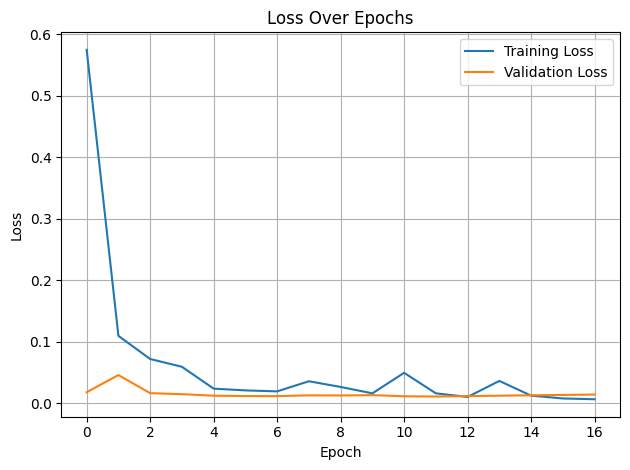

In [10]:
import matplotlib.pyplot as plt


# Plot training & validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


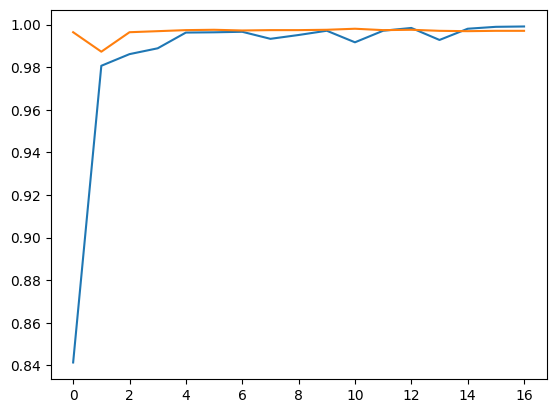

In [11]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

100%|█████████████████████████████████████████████████████████████████████████████████| 36/36 [00:19<00:00,  1.83it/s]


  5/192 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step

2025-08-12 09:58:38.533902: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step


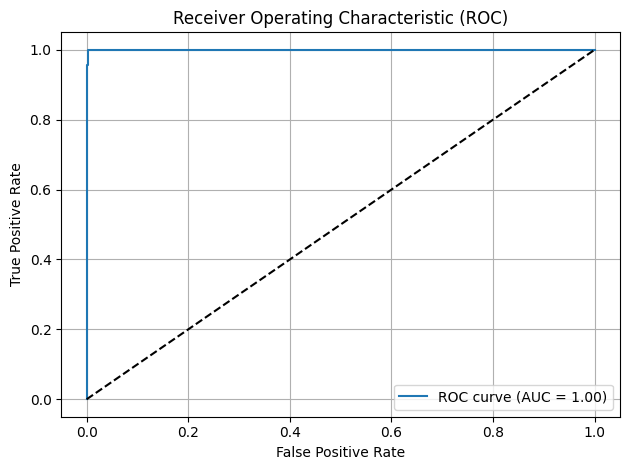

In [12]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = model.predict(X_test).ravel()  # get raw probabilities

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


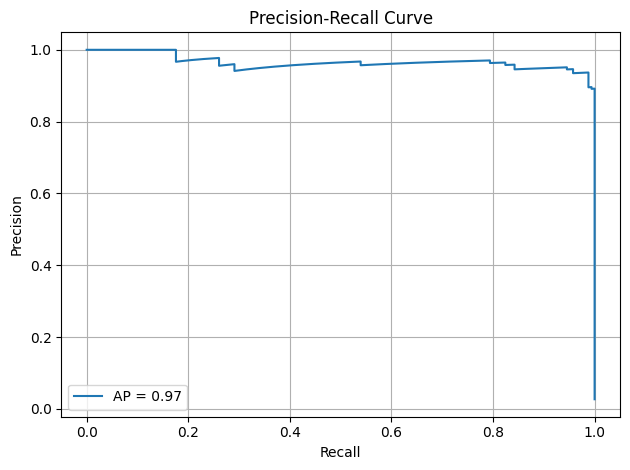

In [13]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

plt.plot(recall, precision, label=f'AP = {avg_prec:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# Model

In [5]:
from tensorflow.keras.models import load_model

model = load_model('model_32layer_seed5_all2.keras')

2025-08-19 14:00:20.823974: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
import numpy as np

def predict_sliding_windows(seq, model, window_size=3000, step=1500):
    
    scores = []
    positions = []

    # Slide through the sequence
    for i in tqdm(range(0, len(seq) - window_size + 1, step)):
        chunk = seq[i:i + window_size]
        
        # One-hot encoded? Already a list of np.array([1,0,0,0]) per base
        # Otherwise, if string-based: encode here
        chunk = [one_hot_encoding(x) for x in chunk]
        X = np.array(chunk).reshape(1, window_size, 4)  # batch of 1
        prob = model.predict(X, verbose=0)[0][0]
        
        scores.append(prob)
        positions.append((i, i + window_size))

    return positions, scores


In [7]:
all_scores = {}
results = {}


# Estimation

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 401/401 [00:30<00:00, 13.11it/s]


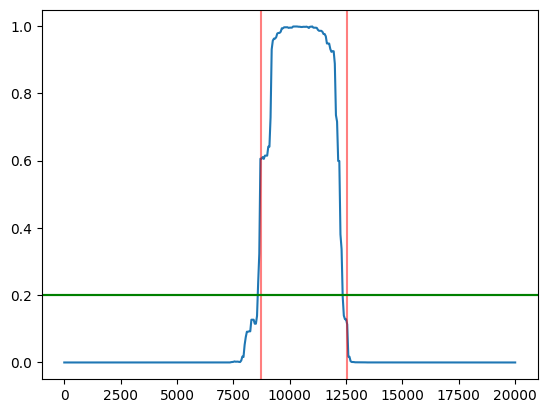

In [72]:
#f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")
#centromeres = pd.read_csv("../../output/estimation/major/Major.csv")

f = FastA("../../data/Fasta/genome.fasta")
centromeres = pd.read_csv("../../output/estimation/donovani/donovani_genome.csv")

centromeres = {
    str(row['Chromosome']): (row['start'], row['end'])
    for _, row in centromeres.iterrows()
}
vecteur_Debut = []
vecteur_Fin = []
vecteur_longeur = []

for chrom in range(1,37):
                
    try:
        seq = f.sequences[f.names.index(str(chrom))]
    
    except:
        seq = f.sequences[chrom-1].upper().replace('N', 'T')
    clf()
    positions, scores = predict_sliding_windows(seq, model)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    axvline(start, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all3/donovani/CNN1_{chrom}_Ldonovani.png")

    positions_ini = positions
    scores_ini = scores

    seq = seq[positions[argmax(scores)][0]-10000:positions[argmax(scores)][1]+10000]
    
    clf()
    positions, scores = predict_sliding_windows(seq, model,SIZE,50)
    _ = plot([x[0] for x in positions], scores)
    start, stop = centromeres[str(chrom)]
    
    start = start-1500
    stop = stop-1500
    
    axvline(start-positions_ini[argmax(scores_ini)][0]+10000, color='r', alpha=0.5)
    axhline(0.2, color='g')
    axvline(stop-positions_ini[argmax(scores_ini)][0]+10000, color='r', alpha=0.5)
    axhline(0.2, color='g')
    savefig(f"./all3/donovaniEstimation/CNN1_{chrom}_Ldonovani.png")


    scores = np.array(scores)
    
    # Trouver le pic principal (avec un seuil si besoin)
    peaks, _ = find_peaks(scores, height=0.2)  # height = seuil minimal
    
    # Si tu veux juste le plus haut pic
    main_peak = peaks[np.argmax(scores[peaks])]
    
    # Calcul de la largeur à mi-hauteur (ou autre niveau)
    widths_result = peak_widths(scores, [main_peak], rel_height=0.5)

    taille = widths_result[0][0]*50
    debut = widths_result[2][0]*50
    fin = widths_result[3][0]*50

    delta = positions_ini[argmax(scores_ini)][0]-10000 + 1500
    vecteur_Debut.append(debut+delta)
    vecteur_Fin.append(fin+delta)
    vecteur_longeur.append(taille)
    
result = pd.DataFrame()
result['Chromosome'] = list(range(1, 37))
result['start'] = vecteur_Debut 
result['end'] = vecteur_Fin
result['length'] = vecteur_longeur
result.to_csv(f"./all3/donovaniEstimation/donovani.csv", index=False)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 401/401 [00:29<00:00, 13.44it/s]

20 (9350, 12350) 0.99992603


NameError: name 'find_peaks' is not defined

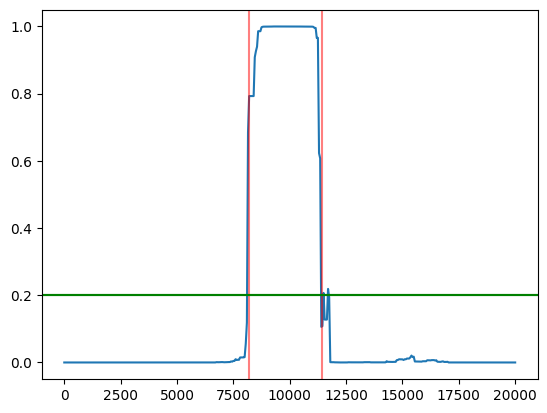

In [34]:
positions_ini = positions
scores_ini = scores
try:
    seq = f.sequences[f.names.index(str(chrom))]

except:
    seq = f.sequences[chrom-1].upper().replace('N', 'T')
seq = seq[positions[argmax(scores)][0]-10000:positions[argmax(scores)][1]+10000]

clf()
positions, scores = predict_sliding_windows(seq, model,SIZE,50)
_ = plot([x[0] for x in positions], scores)
start, stop = centromeres[str(chrom)]

start = start-1500
stop = stop-1500

axvline(start-positions_ini[argmax(scores_ini)][0]+10000, color='r', alpha=0.5)
axhline(0.2, color='g')
axvline(stop-positions_ini[argmax(scores_ini)][0]+10000, color='r', alpha=0.5)
axhline(0.2, color='g')
print(chrom, positions[argmax(scores)], max(scores))
all_scores[chrom] = max(scores)

positions=positions_ini
scores = scores_ini

peaks, properties = find_peaks(temp_,  prominence=mean*2, distance=20)

peak_index = np.argmax(scores)
peak_pos = positions[peak_index][0]  # position de début du pic

# Seuil (50% du max ou 0.2)
threshold = max(scores) * 0.5

# Trouver limite gauche
left_index = peak_index
while left_index > 0 and scores[left_index] > threshold:
    left_index -= 1

# Trouver limite droite
right_index = peak_index
while right_index < len(scores)-1 and scores[right_index] > threshold:
    right_index += 1

# Conversion en paires de bases
peak_start_bp = positions[left_index][0]
peak_end_bp = positions[right_index][1]
peak_size_bp = peak_end_bp - peak_start_bp

print(f"Taille du pic : {peak_size_bp} bases")

In [ ]:
#Predition  sur les génomes

In [ ]:
import numpy as np
from tqdm import tqdm

def predict_sliding_windows(seq, model, window_size=3000, step=1500, batch_size=512):
    scores = []
    positions = []

    windows = []
    pos = []

    # Préparer toutes les fenêtres
    for i in range(0, len(seq) - window_size + 1, step):
        chunk = seq[i:i + window_size]
        chunk = [one_hot_encoding(x) for x in chunk]
        windows.append(chunk)
        pos.append((i, i + window_size))

        # Dès qu'on atteint un batch -> prédire
        if len(windows) == batch_size:
            X = np.array(windows).reshape(len(windows), window_size, 4)
            probs = model.predict(X, verbose=0).reshape(-1)
            scores.extend(probs)
            positions.extend(pos)
            windows, pos = [], []

    # Dernier batch
    if windows:
        X = np.array(windows).reshape(len(windows), window_size, 4)
        probs = model.predict(X, verbose=0).reshape(-1)
        scores.extend(probs)
        positions.extend(pos)

    return positions, scores


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
fin


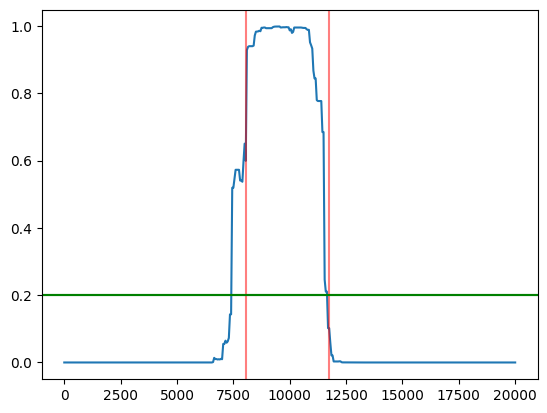

In [22]:
#f = FastA("../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta")
#centromeres = pd.read_csv("../../output/estimation/major/Major.csv")

from pathlib import Path

datas =     [["../../data/Fasta/TriTrypDB-68_LmajorFriedlin_Genome.fasta","../../output/estimation/major/Major.csv","major"],
            #["../../data/Fasta/genomes/Larabica/ragtag.scaffold.fasta","../../output/estimation/arabica.csv","arabica"],
            #["../../data/Fasta/genomes/Laethiopica/ragtag.scaffold.fasta","../../output/estimation/aethiopica.csv","aethiopica"],
            #["../../data/Fasta/genomes/Ltropica/LtropicaRef_genome.fasta","../../output/estimation/tropica.csv","tropica"],
            #["../../data/Fasta/genome.fasta","../../output/estimation/donovani/donovani_genome.csv",[]],
            #["../../data/Fasta/genomes/Linfantum/TriTrypDB-68_LinfantumJPCM5_Genome.fasta","../../output/estimation/infantum.csv","infantum"],
            #["../../data/Fasta/genomes/LamazonensisPH8/ragtag.scaffold.fasta","../../output/estimation/amazonensis.csv","amazonensis"],
            #["../../data/Fasta/genomes/Lmexicana/ragtag.scaffold.fasta","../../output/estimation/mexicana.csv","mexicana"],
            #["../../data/Fasta/genomes/Ltarentolae/ragtag.scaffold.fasta","../../output/estimation/tarentolae.csv","tarentolae"],
            #["../../data/Fasta/genomes/Lbraziliensis/ragtag.scaffold.fasta","../../output/estimation/braziliensis.csv","braziliensis"],
           # ["../../data/Fasta/genomes/Lpanamensis/TriTrypDB-68_LpanamensisMHOMPA94PSC1_Genome.fasta","../../output/estimation/panamensis.csv","panamensis"],]
            #["../../data/Fasta/genomes/Lorientalis/ragtag.scaffold.fasta","../../output/estimation/orientalis.csv","orientalis"],
            #["../../data/Fasta/genomes/Lmartiniquensis/ragtag.scaffold.fasta","../../output/estimation/martiniquensis.csv","martiniquensis"]]
            ]
for data in datas:
    vecteur_Debut = []
    vecteur_Fin = []
    vecteur_longeur = []

    f = FastA(data[0])
    centromeres = pd.read_csv(data[1])
    
    centromeres = {
        str(row['Chromosome']): (row['start'], row['end'])
        for _, row in centromeres.iterrows()
    }

    for chrom in range(1,37):
        print( chrom)           
        try:
            seq = f.sequences[f.names.index(str(chrom))]
        
        except:
            seq = f.sequences[chrom-1].upper().replace('N', 'T')
        clf()
        positions, scores = predict_sliding_windows(seq, model)
        _ = plot([x[0] for x in positions], scores)
        start, stop = centromeres[str(chrom)]
        axvline(start, color='r', alpha=0.5)
        axhline(0.2, color='g')

        dossier = Path(f"./test/{data[2]}/")
        dossier.mkdir(exist_ok=True)
        savefig(f"./test/{data[2]}/CNN1_{chrom}_L{data[2]}.png")
    
        positions_ini = positions
        scores_ini = scores
    
        seq = seq[positions[argmax(scores)][0]-10000:positions[argmax(scores)][1]+10000]
        
        clf()
        positions, scores = predict_sliding_windows(seq, model,SIZE,50)
        _ = plot([x[0] for x in positions], scores)
        start, stop = centromeres[str(chrom)]
        
        start = start-1500
        stop = stop-1500
        
        axvline(start-positions_ini[argmax(scores_ini)][0]+10000, color='r', alpha=0.5)
        axhline(0.2, color='g')
        axvline(stop-positions_ini[argmax(scores_ini)][0]+10000, color='r', alpha=0.5)
        axhline(0.2, color='g')
        dossier = Path(f"./test/{data[2]}Estimation/")
        dossier.mkdir(exist_ok=True)
        savefig(f"./test/{data[2]}Estimation/CNN1_{chrom}_L{data[2]}.png")
    
    
        scores = np.array(scores)
        
        # Trouver le pic principal (avec un seuil si besoin)
        peaks, _ = find_peaks(scores, height=0.2)  # height = seuil minimal
        if len(peaks) != 0:
            # Si tu veux juste le plus haut pic
            main_peak = peaks[np.argmax(scores[peaks])]
            
            # Calcul de la largeur à mi-hauteur (ou autre niveau)
            widths_result = peak_widths(scores, [main_peak], rel_height=0.5)
        
            taille = widths_result[0][0]*50
            debut = widths_result[2][0]*50
            fin = widths_result[3][0]*50
        
            delta = positions_ini[argmax(scores_ini)][0]-10000 + 1500
            vecteur_Debut.append(debut+delta)
            vecteur_Fin.append(fin+delta)
            vecteur_longeur.append(taille)
        else:
            vecteur_Debut.append(0)
            vecteur_Fin.append(0)
            vecteur_longeur.append(0)
        
    result = pd.DataFrame()
    result['Chromosome'] = list(range(1, 37))
    result['start'] = vecteur_Debut 
    result['end'] = vecteur_Fin
    result['length'] = vecteur_longeur
    result.to_csv(f"./test/{data[2]}Estimation/{data[2]}.csv", index=False)
print("fin")

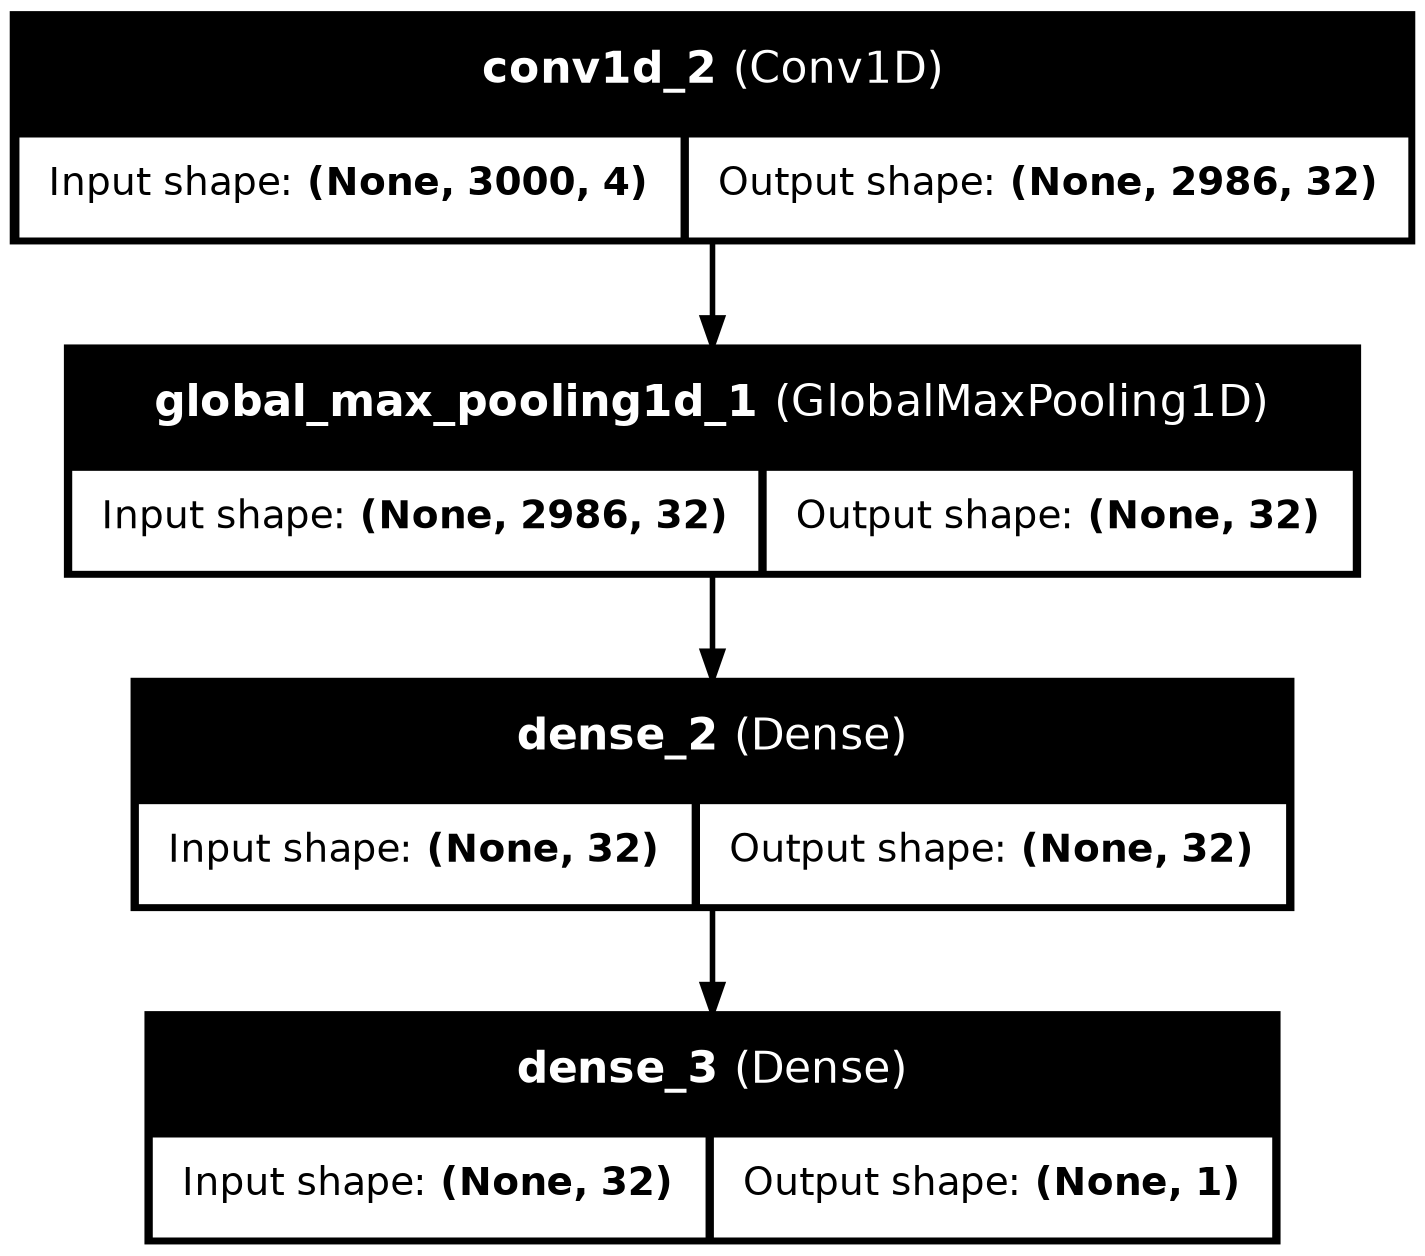

In [5]:
SIZE = 3000
layer_size = 32
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
model = models.Sequential([
    layers.Input(shape=(SIZE, 4)),
    layers.Conv1D(layer_size, kernel_size=15, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(layer_size, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [7]:
pip install pydot graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [graphviz]━━ 1/2 [graphviz]
Note: you may need to restart the kernel to use updated packages.


In [3]:
from tensorflow.keras.utils import plot_model

In [13]:
pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [6]:
model = models.Sequential([
    layers.Input(shape=(SIZE, 4)),
    layers.Conv1D(layer_size, kernel_size=15, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(layer_size, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

In [7]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 2986, 32)       │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,041 (11.88 KB)

 Trainable params: 3,041 (11.88 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
layer_size = 64
model = models.Sequential([
    layers.Input(shape=(SIZE, 4)),
    layers.Conv1D(layer_size, kernel_size=15, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(layer_size*2, kernel_size=10, activation='relu'),
    layers.GlobalMaxPooling1D(),
    layers.Dense(layer_size, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

In [21]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_16 (Conv1D)              │ (None, 2986, 64)       │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 1493, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 1484, 128)      │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_9          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,273 (368.25 KB)

 Trainable params: 94,273 (368.25 KB)

 Non-trainable params: 0 (0.00 B)